# Loan Default Risk Prediction

**Goal:** Predict whether a loan applicant is likely to default (`Risk_Flag`) using applicant demographic, financial, and employment data.

**Approach:**
- Exploratory data analysis to understand feature distributions and relationships with the target
- Feature engineering (age grouping, job stability ratio) and categorical encoding (binary, one-hot, frequency, ordinal)
- Compared Logistic Regression, Decision Tree, and Random Forest using Stratified K-Fold cross-validation, scored on ROC-AUC due to class imbalance
- Hyperparameter tuning via GridSearchCV on the best-performing model (Random Forest)
- Evaluated the final model with ROC-AUC, H-Measure, and a lift curve to assess real-world usefulness for identifying high-risk applicants

**Tech stack:** Python, Pandas, Scikit-learn, Seaborn/Matplotlib


In [37]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import normalize
#from sklearn.metrics import mean_squared_error

In [38]:
train_data= pd.read_csv("train_data.csv")

In [39]:
train_data.head(30)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
5,6,6915937,64,0,single,rented,no,Civil_servant,Jalgaon,Maharashtra,0,12,0
6,7,3954973,58,14,married,rented,no,Librarian,Tiruppur,Tamil_Nadu,8,12,0
7,8,1706172,33,2,single,rented,no,Economist,Jamnagar,Gujarat,2,14,0
8,9,7566849,24,17,single,rented,yes,Flight_attendant,Kota[6],Rajasthan,11,11,0
9,10,8964846,23,12,single,rented,no,Architect,Karimnagar,Telangana,5,13,0


In [4]:
train_data.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


**Observations:** No skewness or outliers in numerical columns. Income varies greatly compared to other columns.

In [5]:
train_data.count()

Id                   252000
Income               252000
Age                  252000
Experience           252000
Married/Single       252000
House_Ownership      252000
Car_Ownership        252000
Profession           252000
CITY                 252000
STATE                252000
CURRENT_JOB_YRS      252000
CURRENT_HOUSE_YRS    252000
Risk_Flag            252000
dtype: int64

In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB


In [7]:
train_data.duplicated().sum()

np.int64(0)

**Observations:** No missing values or duplicates.

## Relationship Between Features and Target

In [8]:
city_default_rates= train_data.groupby('CITY')['Risk_Flag'].mean()
print(city_default_rates.sort_values(ascending=False))

CITY
Bhubaneswar         0.326194
Gwalior             0.272727
Bettiah[33]         0.266958
Kochi               0.252862
Raiganj             0.239554
                      ...   
Bangalore           0.037139
Bijapur             0.034965
Sultan_Pur_Majra    0.034091
Dehradun            0.026346
Gandhinagar         0.026114
Name: Risk_Flag, Length: 317, dtype: float64


In [9]:
profession_default_rates= train_data.groupby('Profession')['Risk_Flag'].mean()
print(profession_default_rates.sort_values(ascending=False))

Profession
Police_officer                0.164052
Chartered_Accountant          0.153572
Army_officer                  0.152113
Surveyor                      0.151464
Software_Developer            0.148427
Scientist                     0.144321
Geologist                     0.144264
Civil_engineer                0.135832
Official                      0.135796
Firefighter                   0.135789
Air_traffic_controller        0.135391
Hotel_Manager                 0.135380
Aviator                       0.134931
Technical_writer              0.134167
Architect                     0.131200
Secretary                     0.130409
Lawyer                        0.129514
Computer_hardware_engineer    0.128444
Technician                    0.128289
Biomedical_Engineer           0.127560
Consultant                    0.125208
Microbiologist                0.124360
Computer_operator             0.124048
Flight_attendant              0.123635
Artist                        0.122609
Psychologist  

In [10]:
state_default_rates= train_data.groupby('STATE')['Risk_Flag'].mean()
print(state_default_rates.sort_values(ascending=False))

STATE
Manipur              0.215548
Tripura              0.168109
Kerala               0.167097
Jammu_and_Kashmir    0.158989
Madhya_Pradesh       0.154369
Odisha               0.142550
Rajasthan            0.140833
Jharkhand            0.133296
Chhattisgarh         0.133281
Himachal_Pradesh     0.133253
Assam                0.131691
Bihar                0.130586
Uttar_Pradesh[5]     0.130552
Telangana            0.130117
West_Bengal          0.128135
Haryana              0.124208
Gujarat              0.117724
Uttar_Pradesh        0.117711
Puducherry           0.116539
Andhra_Pradesh       0.116022
Maharashtra          0.113254
Mizoram              0.110718
Delhi                0.104554
Tamil_Nadu           0.103163
Karnataka            0.100295
Chandigarh           0.092988
Punjab               0.090042
Uttarakhand          0.070971
Sikkim               0.046053
Name: Risk_Flag, dtype: float64


In [11]:
car_default_rates= train_data.groupby('Car_Ownership')['Risk_Flag'].mean()
print(car_default_rates.sort_values(ascending=False))

Car_Ownership
no     0.128188
yes    0.110987
Name: Risk_Flag, dtype: float64


In [12]:
house_default_rates= train_data.groupby('House_Ownership')['Risk_Flag'].mean()
print(house_default_rates.sort_values(ascending=False))

House_Ownership
rented          0.125577
norent_noown    0.099527
owned           0.089797
Name: Risk_Flag, dtype: float64


In [13]:
marriage_default_rates= train_data.groupby('Married/Single')['Risk_Flag'].mean()
print(marriage_default_rates.sort_values(ascending=False))

Married/Single
single     0.125336
married    0.102456
Name: Risk_Flag, dtype: float64


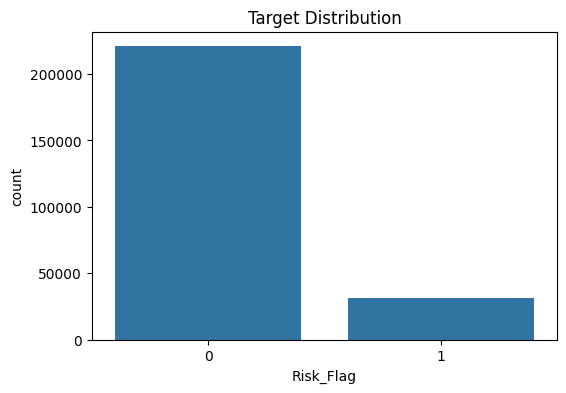

In [15]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Flag', data=train_data)
plt.title("Target Distribution")
plt.show()

**Note:** Target variable is imbalanced — will use `class_weight='balanced'` and ROC-AUC instead of accuracy.

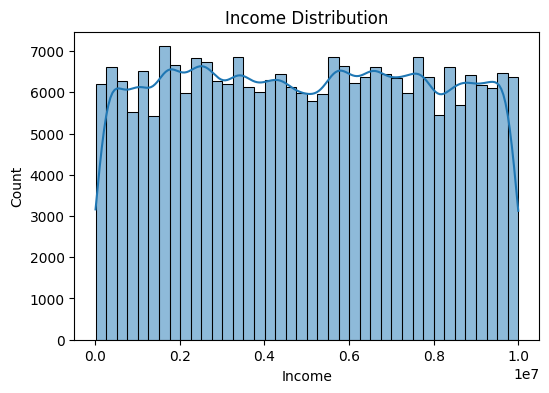

In [16]:
# Income distribution
plt.figure(figsize=(6,4))
sns.histplot(train_data['Income'], bins=40, kde=True)
plt.title("Income Distribution")
plt.show()

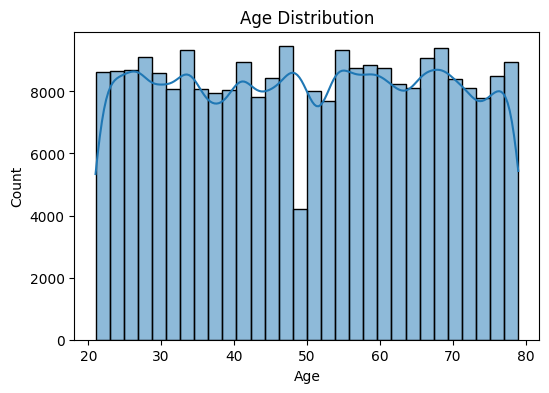

In [17]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

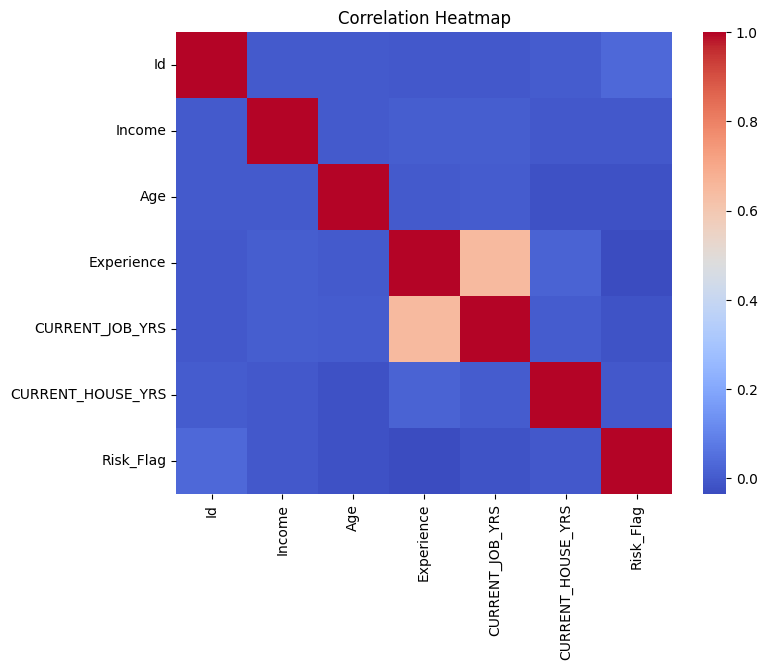

In [18]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(train_data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#correlations matrix
numerical_data= train_data.select_dtypes(include= ['float64', 'int64'])
correlations= numerical_data.corr()
print(correlations)

In [ ]:
# Conclusion: keep all features for now (no strong multicollinearity issues found)

## Outlier Check (IQR Method)

In [ ]:
Q1 = train_data['Income'].quantile(0.25)
Q3 = train_data['Income'].quantile(0.75)
IQR = Q3 - Q1
outliers = train_data[(train_data['Income'] < Q1 - 1.5*IQR) | (train_data['Income'] > Q3 + 1.5*IQR)]
print(outliers)

**Result:** No outliers detected in Income.

## Feature Engineering

**Step:** Convert `Age` into an `age_group` categorical column.

In [40]:
bins = [18, 34, 54, 100]
labels = ['young', 'middle', 'old']
train_data['age_group'] = pd.cut(train_data['Age'], bins=bins, labels=labels, right=True)
train_data= train_data.drop('Age', axis= 1)

**Step:** Add a `job_stability_ratio` feature (current job years / total experience).

In [41]:
train_data['job_stability_ratio'] = train_data['CURRENT_JOB_YRS']/train_data['Experience']

In [42]:
train_data.head()

,Id,Income,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,age_group,job_stability_ratio
0,1,1303834,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0,young,1.000000
1,2,7574516,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0,middle,0.900000
2,3,3991815,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0,old,1.000000
3,4,6256451,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1,middle,1.000000
4,5,5768871,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1,middle,0.272727


In [43]:
#to check dataset after feature engineering
train_data.describe()

,Id,Income,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,job_stability_ratio
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,240957.000000
mean,126000.500000,4.997117e+06,10.084437,6.333877,11.997794,0.123000,0.736677
std,72746.278255,2.878311e+06,6.002590,3.647053,1.399037,0.328438,0.280127
min,1.000000,1.031000e+04,0.000000,0.000000,10.000000,0.000000,0.150000
25%,63000.750000,2.503015e+06,5.000000,3.000000,11.000000,0.000000,0.500000
50%,126000.500000,5.000694e+06,10.000000,6.000000,12.000000,0.000000,0.818182
75%,189000.250000,7.477502e+06,15.000000,9.000000,13.000000,0.000000,1.000000
max,252000.000000,9.999938e+06,20.000000,14.000000,14.000000,1.000000,1.000000


**Note:** Missing values appear in `job_stability_ratio` (likely from zero experience) — filled with median.

In [44]:
train_data['job_stability_ratio'].isnull().sum()

np.int64(11043)

In [45]:
job_stability_median = train_data['job_stability_ratio'].median()
train_data['job_stability_ratio']= train_data['job_stability_ratio'].fillna(job_stability_median)

In [46]:
train_data['job_stability_ratio'].isnull().sum()

np.int64(0)

## Encoding Categorical Features

**1. Binary encoding** for two-class categorical columns:

In [47]:
train_data['Married/Single']= train_data['Married/Single'].map({'single': 0, 'married': 1})
train_data['Car_Ownership']= train_data['Car_Ownership'].map({'no': 0, 'yes': 1})

**2. One-Hot Encoding** for multi-class categorical columns:

In [48]:
#number of categories in categorical columns

In [49]:
train_data['STATE'].nunique()

29

In [50]:
train_data['CITY'].nunique()

317

In [51]:
train_data['Profession'].nunique()

51

In [52]:
train_data['House_Ownership'].nunique()

3

**Applying OHE** to State, Profession, and House Ownership columns.

In [53]:
train_data= pd.get_dummies(train_data, columns= ['STATE','Profession','House_Ownership'], drop_first=True)

**3. Frequency encoding** for the City column (too many unique categories for OHE).

In [54]:
city_freq= train_data['CITY'].value_counts(normalize= True)
train_data['city_encoded']= train_data['CITY'].map(city_freq)
train_data= train_data.drop('CITY', axis= 1)

**4. Ordinal encoding** for the engineered age_group column.

In [55]:
map= {"young":0, "middle":1, "old":2}

In [56]:
train_data['age_group']= train_data['age_group'].map(map)

In [57]:
train_data.head()

,Id,Income,Experience,Married/Single,Car_Ownership,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,age_group,job_stability_ratio,...,Profession_Statistician,Profession_Surgeon,Profession_Surveyor,Profession_Technical_writer,Profession_Technician,Profession_Technology_specialist,Profession_Web_designer,House_Ownership_owned,House_Ownership_rented,city_encoded
0,1,1303834,3,0,0,3,13,0,0,1.000000,...,False,False,False,False,False,False,False,False,True,0.003167
1,2,7574516,10,0,0,9,13,0,1,0.900000,...,False,False,False,False,False,False,False,False,True,0.003369
2,3,3991815,4,1,0,4,10,0,2,1.000000,...,False,False,False,True,False,False,False,False,True,0.002730
3,4,6256451,2,0,1,2,12,1,1,1.000000,...,False,False,False,False,False,False,False,False,True,0.002409
4,5,5768871,11,0,0,3,14,1,1,0.272727,...,False,False,False,False,False,False,False,False,True,0.003210


In [58]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Risk_Flag', axis=1)
y = train_data['Risk_Flag']

X_train, X_val, y_train, y_val= train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [59]:
#train_data.head()

## Model Building

Using a separate pipeline for Logistic Regression to apply feature standardization (not needed for tree-based models).

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [64]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [65]:
dt_model = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced') )
])

In [66]:
rf_model = Pipeline([
    ('model', RandomForestClassifier(n_estimators= 100, max_depth= 10, n_jobs=-1, random_state=42, class_weight='balanced') )
])

In [67]:
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

In [95]:
log_scores = cross_val_score(log_model, X_train, y_train, cv=skf, scoring='roc_auc')
print("Logistic Regression: ", log_scores)

Logistic Regression:  [0.57615725 0.58088197 0.59245045 0.58431891]


In [96]:
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=skf, scoring='roc_auc')
print("Decision Tree: ", dt_scores)

Decision Tree:  [0.68662451 0.70165408 0.6980151  0.68356663]


In [97]:
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='roc_auc')
print("Random Forest: ", rf_scores)

Random Forest:  [0.75273215 0.76118514 0.77407993 0.7647502 ]


**Result:** Random Forest achieved the best cross-validated ROC-AUC score among the three models.

In [68]:
param_grid= {
    "model__n_estimators":[100],
    "model__max_depth": [8,12],
    "model__min_samples_leaf": [1,5],
    "model__min_samples_split": [2],
    "model__class_weight": ['balanced']
}

In [69]:
grid = GridSearchCV(
    estimator= rf_model,
    param_grid= param_grid,
    scoring= 'roc_auc',
    cv= skf,
    n_jobs=-1,
    verbose= 3
)

In [70]:
grid.fit(X_train,y_train)

Fitting 4 folds for each of 4 candidates, totalling 16 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced'], 'model__max_depth': [8, 12], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [71]:
grid.best_params_

{'model__class_weight': 'balanced',
 'model__max_depth': 12,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [72]:
grid.best_score_

np.float64(0.7987602441730954)

In [73]:
best_model= grid.best_estimator_

In [ ]:
## Model Evaluation: H-Measure and Lift Curve

Using additional metrics beyond ROC-AUC to better evaluate performance on this imbalanced classification problem.

In [2]:
y_val_prob= best_model.predict_proba(X_val)[:,1]

NameError: name 'best_model' is not defined

In [ ]:
**H-Measure** — a metric robust to class imbalance and misclassification cost asymmetry.

In [ ]:
from hmeasure import h_score

h= h_score(y_val, y_val_prob)
print("H-Measure: ", h)

In [ ]:
**Lift Curve** — shows how much better the model is at identifying defaults compared to random selection.

In [ ]:
#evaluation dataframe
lift_df= pd.DataFrame({
    'actual': y_val,
    'prob': y_val_prob
})
# sor by predicted probability 
lift_df= lift_df.sort_values(by='prob', ascending= False)

#cumulative calculations
lift_df['cum_defaults'] = lift_df['actual'].cumsum()
lift_df['population_pct'] = np.arange(1, len(lift_df)+1) / len(lift_df)
lift_df['capture_rate'] = lift_df['cum_defaults'] / lift_df['actual'].sum()

In [ ]:
#plot
plt.figure(figsize=(6,6))

plt.plot(lift_df['population_pct'], lift_df['capture_rate'], label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Random')

plt.xlabel("Percentage of Population")
plt.ylabel("Percentage of Defaults Captured")
plt.title("Lift Curve")
plt.legend()

plt.show()


In [ ]:
# lift at top 10%
top_10 = lift_df.head(int(0.1 * len(lift_df)))

lift_10 = top_10['actual'].mean() / lift_df['actual'].mean()

print("Lift at 10%:", lift_10)


In [74]:
test_data= pd.read_csv("Test Data.csv")

## Preparing Test Data

Applying the same feature engineering and encoding steps used on the training data.

In [75]:
test_data.head(20)

,ID,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1,7393090,59,19,single,rented,no,Geologist,Malda,West Bengal,4,13
1,2,1215004,25,5,single,rented,no,Firefighter,Jalna,Maharashtra,5,10
2,3,8901342,50,12,single,rented,no,Lawyer,Thane,Maharashtra,9,14
3,4,1944421,49,9,married,rented,yes,Analyst,Latur,Maharashtra,3,12
4,5,13429,25,18,single,rented,yes,Comedian,Berhampore,West Bengal,13,11
5,6,3437621,78,14,single,rented,no,Economist,Ramgarh,Jharkhand,3,10
6,7,5101498,55,0,married,rented,no,Artist,Pallavaram,Tamil Nadu,0,14
7,8,6716946,70,15,single,rented,yes,Flight attendant,Yamunanagar,Haryana,14,13
8,9,8369802,43,7,single,rented,no,Secretary,Anand,Gujarat,6,13
9,10,9565457,65,5,single,rented,yes,Engineer,Nandyal,Andhra Pradesh,3,12


In [76]:

test_data['age_group'] = pd.cut(test_data['Age'], bins=bins, labels=labels, right=True)
test_data= test_data.drop('Age', axis= 1)

In [77]:
test_data['job_stability_ratio'] = test_data['CURRENT_JOB_YRS']/test_data['Experience']

In [78]:
job_stability_median = test_data['job_stability_ratio'].median()
test_data['job_stability_ratio']= test_data['job_stability_ratio'].fillna(job_stability_median)

In [79]:
test_data['Married/Single']= test_data['Married/Single'].map({'single': 0, 'married': 1})
test_data['Car_Ownership']= test_data['Car_Ownership'].map({'no': 0, 'yes': 1})

In [80]:
test_data= pd.get_dummies(test_data, columns= ['STATE','Profession','House_Ownership'], drop_first=True)

In [81]:
city_freq= test_data['CITY'].value_counts(normalize= True)
test_data['city_encoded']= test_data['CITY'].map(city_freq)
test_data= test_data.drop('CITY', axis= 1)

In [82]:
test_data['age_group']= test_data['age_group'].map(map)

In [83]:
test_data.head(20)

,ID,Income,Experience,Married/Single,Car_Ownership,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,age_group,job_stability_ratio,STATE_Assam,...,Profession_Statistician,Profession_Surgeon,Profession_Surveyor,Profession_Technical writer,Profession_Technician,Profession_Technology specialist,Profession_Web designer,House_Ownership_owned,House_Ownership_rented,city_encoded
0,1,7393090,19,0,0,4,13,2,0.210526,False,...,False,False,False,False,False,False,False,False,True,0.003500
1,2,1215004,5,0,0,5,10,0,1.000000,False,...,False,False,False,False,False,False,False,False,True,0.002893
2,3,8901342,12,0,0,9,14,1,0.750000,False,...,False,False,False,False,False,False,False,False,True,0.003500
3,4,1944421,9,1,1,3,12,1,0.333333,False,...,False,False,False,False,False,False,False,False,True,0.002429
4,5,13429,18,0,1,13,11,0,0.722222,False,...,False,False,False,False,False,False,False,False,True,0.003464
5,6,3437621,14,0,0,3,10,2,0.214286,False,...,False,False,False,False,False,False,False,False,True,0.002393
6,7,5101498,0,1,0,0,14,2,0.800000,False,...,False,False,False,False,False,False,False,False,True,0.004429
7,8,6716946,15,0,1,14,13,2,0.933333,False,...,False,False,False,False,False,False,False,False,True,0.002179
8,9,8369802,7,0,0,6,13,1,0.857143,False,...,False,False,False,False,False,False,False,False,True,0.003964
9,10,9565457,5,0,1,3,12,2,0.600000,False,...,False,False,False,False,False,False,False,False,True,0.004107


In [85]:
test_data.rename(columns={'ID':'Id'}, inplace=True)

In [87]:
test_data = test_data.reindex(columns=X_train.columns, fill_value=0)

In [88]:
y_test_pred= best_model.predict(test_data)

In [89]:
test_data['Predicted_Risk_Flag']= y_test_pred

In [90]:
test_data.head()

,Id,Income,Experience,Married/Single,Car_Ownership,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,age_group,job_stability_ratio,STATE_Assam,...,Profession_Surgeon,Profession_Surveyor,Profession_Technical_writer,Profession_Technician,Profession_Technology_specialist,Profession_Web_designer,House_Ownership_owned,House_Ownership_rented,city_encoded,Predicted_Risk_Flag
0,1,7393090,19,0,0,4,13,2,0.210526,False,...,False,False,0,False,0,0,False,True,0.003500,0
1,2,1215004,5,0,0,5,10,0,1.000000,False,...,False,False,0,False,0,0,False,True,0.002893,1
2,3,8901342,12,0,0,9,14,1,0.750000,False,...,False,False,0,False,0,0,False,True,0.003500,0
3,4,1944421,9,1,1,3,12,1,0.333333,False,...,False,False,0,False,0,0,False,True,0.002429,0
4,5,13429,18,0,1,13,11,0,0.722222,False,...,False,False,0,False,0,0,False,True,0.003464,0
